In [1]:
import astropy

print(astropy.__version__)

8.0.1


In [4]:
import matplotlib.pyplot as plt

%matplotlib inline
import numpy as np

from astropy import units as u
from astropy.coordinates import SkyCoord, Distance
from astropy.table import QTable

from astroquery.gaia import Gaia

Gaia.ROW_LIMIT = 10000  # Set the row limit for returned data

In [5]:
ngc188_center = SkyCoord(12.11 * u.deg, 85.26 * u.deg)
ngc188_center

<SkyCoord (ICRS): (ra, dec) in deg
    (12.11, 85.26)>

In [ ]:
# Aunque el sistema de referencia predeterminado es ICRS, generalmente se 
# recomienda especificar explícitamente el sistema de referencia en el que se encuentran sus coordenadas
ngc188_center = SkyCoord(12.11 * u.deg, 85.26 * u.deg, frame="icrs")
ngc188_center

<SkyCoord (ICRS): (ra, dec) in deg
    (12.11, 85.26)>

In [7]:
ngc188_center = SkyCoord.from_name("NGC 188")
ngc188_center

<SkyCoord (ICRS): (ra, dec) in deg
    (11.79791667, 85.24388889)>

In [8]:
(ngc188_center.ra.hour, ngc188_center.ra.radian, ngc188_center.ra.degree)

(np.float64(0.7865277780000001),
 np.float64(0.2059124907674253),
 np.float64(11.79791667))

In [ ]:
# Consultando el archivo Gaia para recuperar las coordenadas de las estrellas en NGC 188 (requiere conexión a Internet)
job = Gaia.cone_search_async(ngc188_center, radius=0.5 * u.deg)
ngc188_table = job.get_results()

# only keep stars brighter than G=19 magnitude
ngc188_table = ngc188_table[ngc188_table["phot_g_mean_mag"] < 19 * u.mag]

INFO: Query finished. [astroquery.utils.tap.core]


In [10]:
cols = [
    "source_id",
    "ra",
    "dec",
    "parallax",
    "parallax_error",
    "pmra",
    "pmdec",
    "radial_velocity",
    "phot_g_mean_mag",
    "phot_bp_mean_mag",
    "phot_rp_mean_mag",
]
ngc188_table[cols].write("gaia_results.fits", overwrite=True)

In [12]:
ngc188_table = QTable.read("gaia_results.fits")
len(ngc188_table)

4876

In [13]:
ngc188_table["ra"]
ngc188_table["dec"]

<Quantity [85.24193164, 85.24362655, 85.24714775, ..., 84.82022851,
           85.68315506, 84.83926755] deg>

In [14]:
ngc188_gaia_coords = SkyCoord(ngc188_table["ra"], ngc188_table["dec"])
ngc188_gaia_coords

<SkyCoord (ICRS): (ra, dec) in deg
    [(11.77583082, 85.24193164), (11.83025781, 85.24362655),
     (11.78143038, 85.24714775), ..., (14.5384314 , 84.82022851),
     (14.41522696, 85.68315506), (14.90600519, 84.83926755)]>

In [15]:
ngc188_center.to_string(style="hmsdms", sep=":", precision=1)

'00:47:11.5 +85:14:38.0'

In [16]:
ngc188_gaia_coords.separation(ngc188_center)

<Angle [0.0026806 , 0.00269443, 0.00353376, ..., 0.4854874 , 0.485491  ,
        0.48553984] deg>

In [17]:
ngc188_center_3d = SkyCoord(12.11 * u.deg, 85.26 * u.deg, distance=1.96 * u.kpc)

In [18]:
parallax_snr = ngc188_table["parallax"] / ngc188_table["parallax_error"]
ngc188_table_3d = ngc188_table[parallax_snr > 10]
len(ngc188_table_3d)

2423

In [22]:
Distance(parallax=1 * u.mas)

<Distance 1000. pc>

In [23]:
gaia_dist = Distance(parallax=ngc188_table_3d["parallax"].filled(np.nan))

In [24]:
ngc188_coords_3d = SkyCoord(
    ra=ngc188_table_3d["ra"], dec=ngc188_table_3d["dec"], distance=gaia_dist
)
ngc188_coords_3d

<SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, pc)
    [(11.77583082, 85.24193164, 1819.25788676),
     (11.83025781, 85.24362655, 2113.23414411),
     (11.79608811, 85.24947769, 1878.68206887), ...,
     (14.5384314 , 84.82022851, 3339.63434769),
     (14.41522696, 85.68315506, 1167.55221538),
     (14.90600519, 84.83926755, 1297.85616009)]>

Text(0.5, 1.0, 'Gaia DR2 sources near NGC 188')

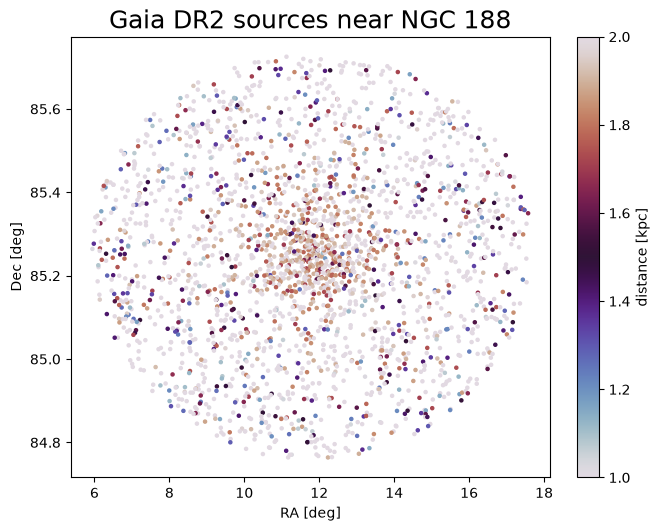

In [27]:
fig, ax = plt.subplots(figsize=(6.5, 5.2), constrained_layout=True)
cs = ax.scatter(
    ngc188_coords_3d.ra.degree,
    ngc188_coords_3d.dec.degree,
    c=ngc188_coords_3d.distance.kpc,
    s=5,
    vmin=1,
    vmax=2,
    cmap="twilight",
)
cb = fig.colorbar(cs)
cb.set_label(f"distance [{u.kpc:latex_inline}]")

ax.set_xlabel("RA [deg]")
ax.set_ylabel("Dec [deg]")

ax.set_title("Gaia DR2 sources near NGC 188", fontsize=18)

In [26]:
sep3d = ngc188_coords_3d.separation_3d(ngc188_center_3d)
sep3d

<Distance [ 140.74632654,  153.23745529,   81.32334553, ..., 1379.80587983,
            792.54107123,  662.28139736] pc>

Ejercicio: Utilizando los valores de separación 3D, defina una máscara booleana para seleccionar posibles miembros del cúmulo. Seleccione todas las estrellas dentro de un radio de 50 pc del centro del cúmulo. ¿Cuántos miembros candidatos de NGC 188 tenemos, basándonos en sus posiciones 3D?

In [28]:
ngc188_3d_mask = sep3d < 50 * u.pc

In [29]:
ngc188_3d_mask.sum()

np.int64(262)